In [2]:
!pip install shap

In [3]:
# Load dataset
import shap
X, y = shap.datasets.adult()

In [5]:
X.head()

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,7,13.0,4,1,0,4,1,2174.0,0.0,40.0,39
1,50.0,6,13.0,2,4,4,4,1,0.0,0.0,13.0,39
2,38.0,4,9.0,0,6,0,4,1,0.0,0.0,40.0,39
3,53.0,4,7.0,2,6,4,2,1,0.0,0.0,40.0,39
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5


In [8]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [9]:
import xgboost
X_train = xgboost.DMatrix(X_train, label=y_train)
X_test = xgboost.DMatrix(X_test, label=y_test)

In [10]:
# Training xgboost model
import numpy as np

params = {
    "eta": 0.01,
    "objective": "binary:logistic",
    "subsample": 0.5,
    "base_score": np.mean(y_train),
    "eval_metric": "logloss",
}

model = xgboost.train(
    params,
    X_train,
    5000,
    evals=[(X_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=20,
)

[0]	test-logloss:0.54737
[100]	test-logloss:0.36070
[200]	test-logloss:0.31331
[300]	test-logloss:0.29551
[400]	test-logloss:0.28689
[500]	test-logloss:0.28173
[600]	test-logloss:0.27866
[700]	test-logloss:0.27670
[800]	test-logloss:0.27557
[900]	test-logloss:0.27459
[1000]	test-logloss:0.27407
[1074]	test-logloss:0.27384


# Plotting XGBooost Feature importance metrics

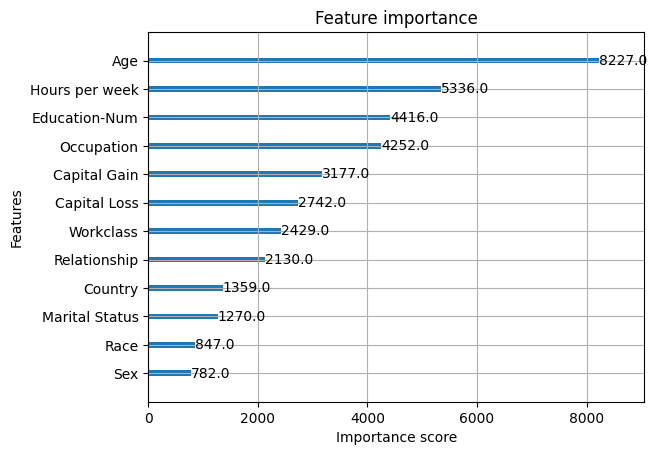

In [12]:
# weight -> measures how often a feature was used in tree splits
import matplotlib.pyplot as plt
xgboost.plot_importance(model, importance_type="weight")
plt.show()

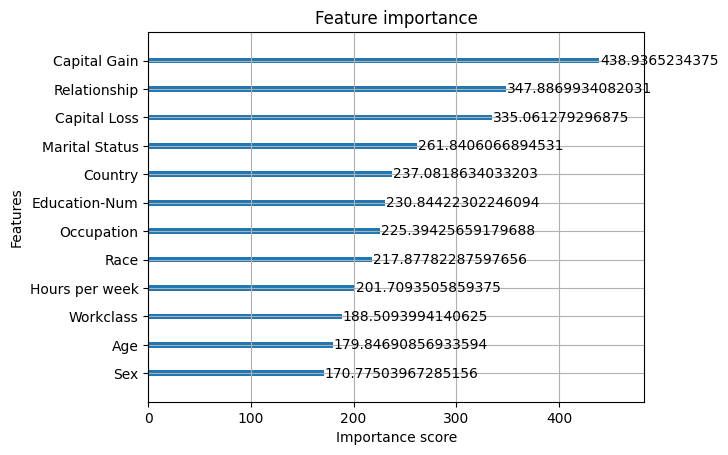

In [13]:
# cover -> measures how many data samples were affected by splits using this feature
xgboost.plot_importance(model, importance_type="cover")
plt.show()

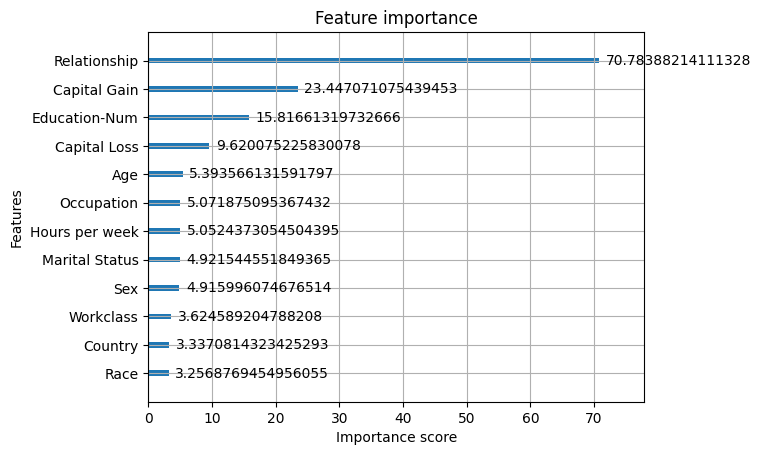

In [14]:
# gain -> measures how much did this feature improves model accuracy
xgboost.plot_importance(model, importance_type="gain")
plt.show()

# Shap explainer

In [15]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

In [16]:
import plotly.io as pio
pio.renderers.default = 'colab'
shap.initjs()

# Explain one instance
shap.force_plot(explainer.expected_value, shap_values[100, :], X.iloc[100, :])

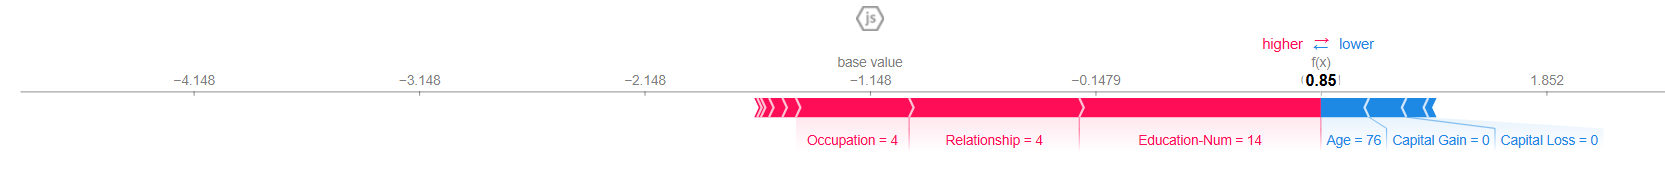

In [17]:
pio.renderers.default = 'colab'
shap.initjs()

# Explain 1000 samples
shap.force_plot(explainer.expected_value, shap_values[:1000, :], X.iloc[:1000, :])

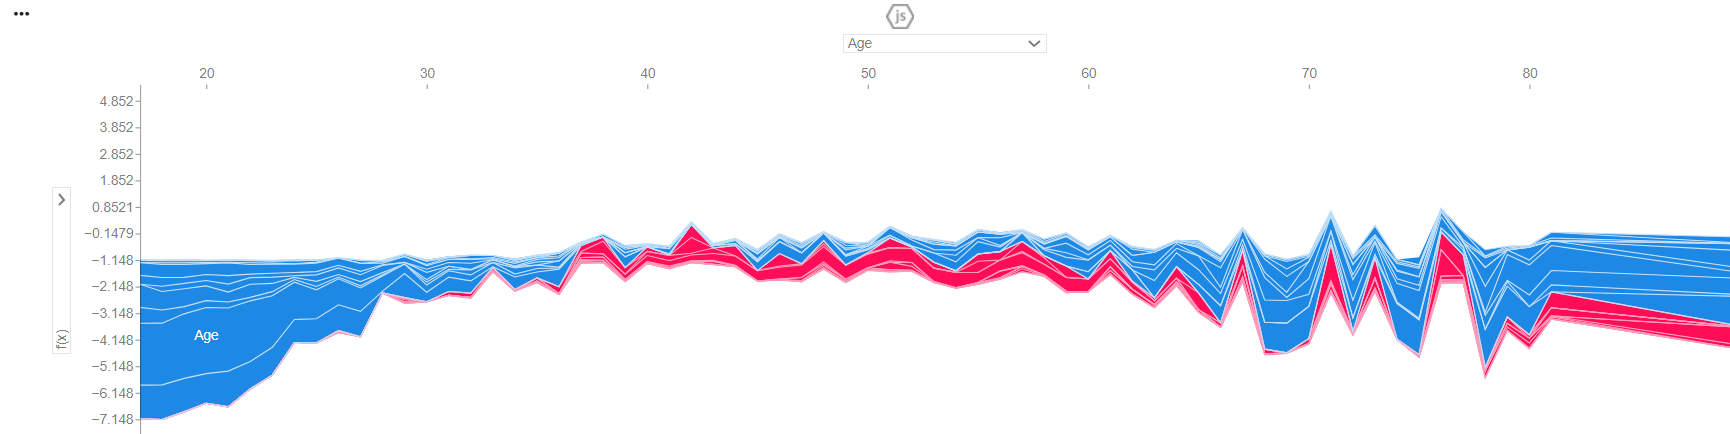

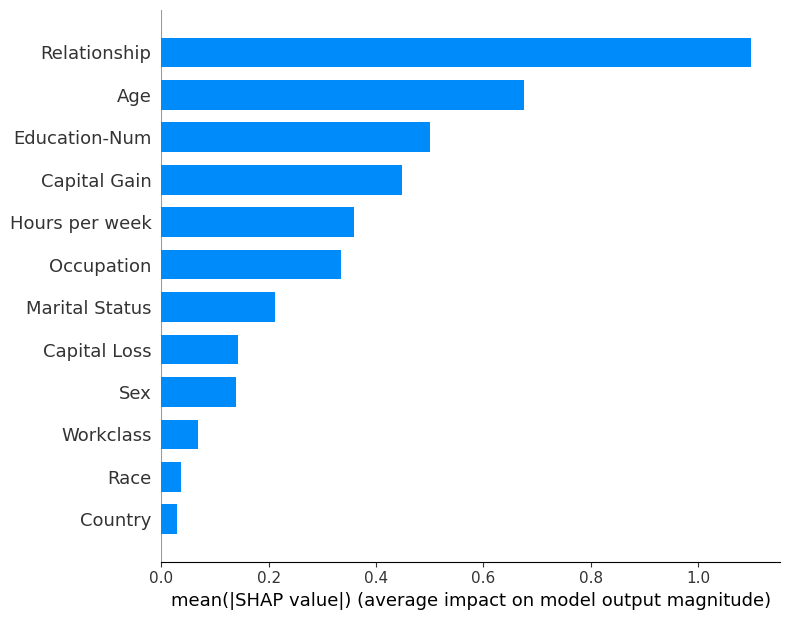

In [19]:
# Shap Summary plot (bar)
shap.summary_plot(shap_values, X, plot_type="bar")

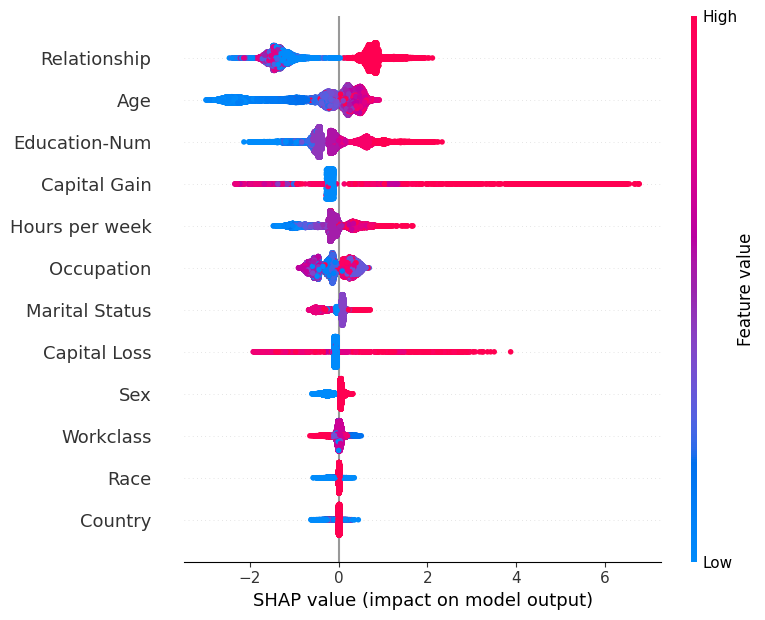

In [20]:
# Shap Summary plot
shap.summary_plot(shap_values, X)

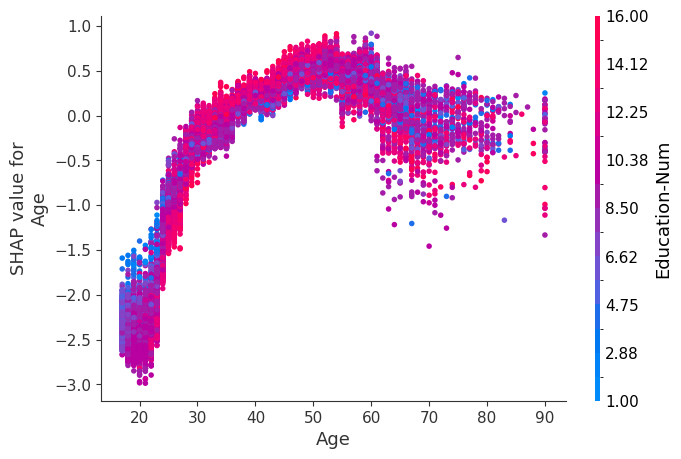

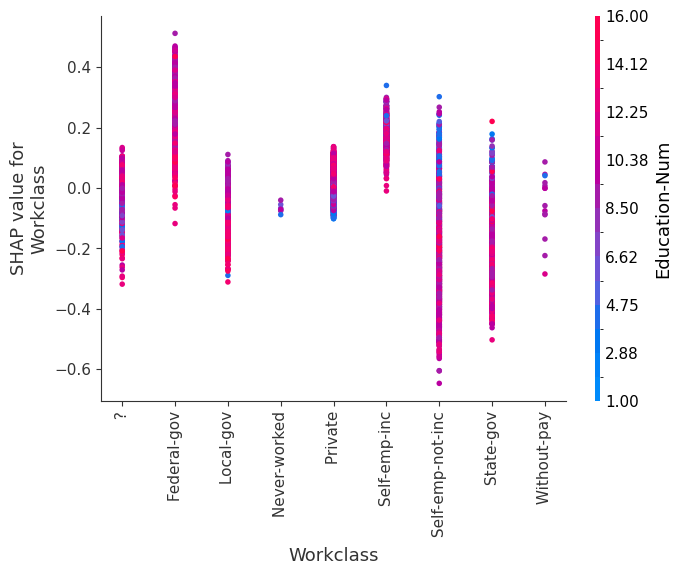

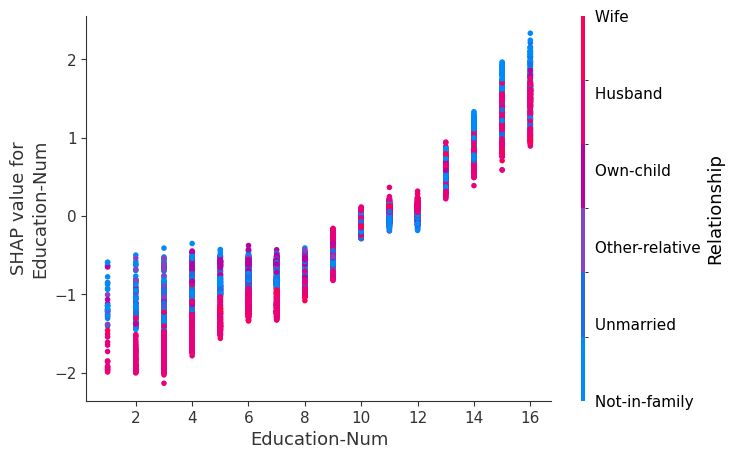

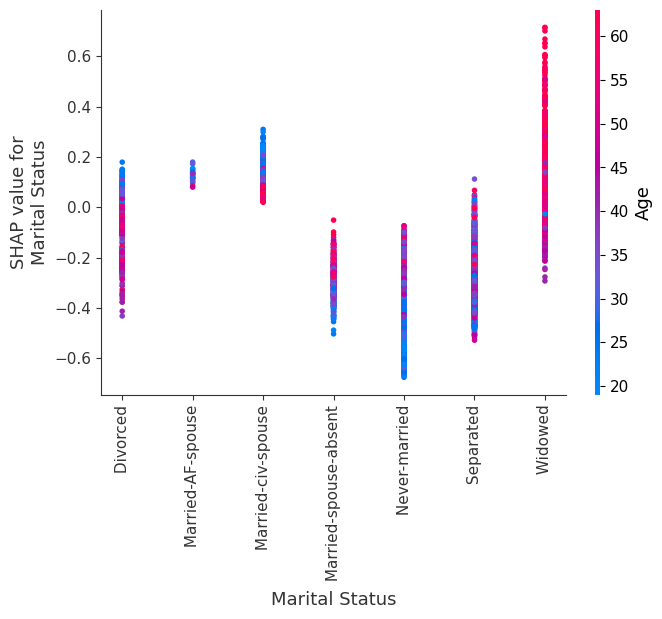

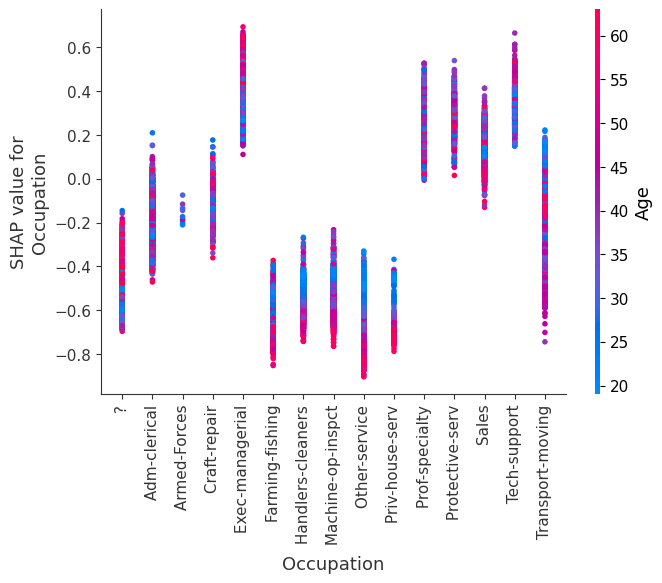

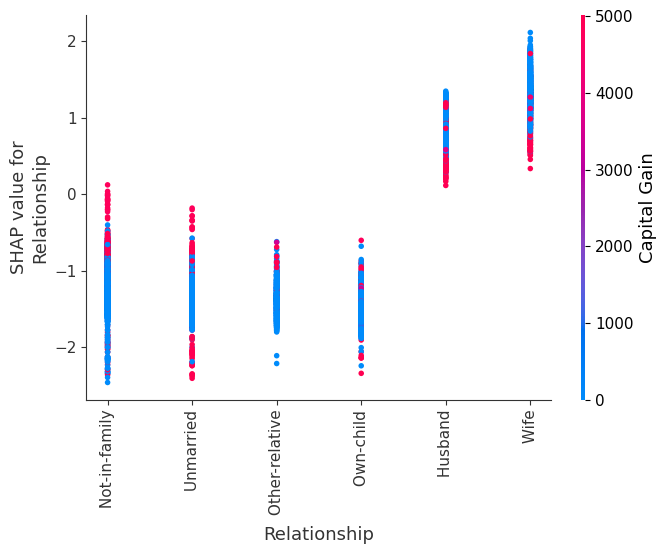

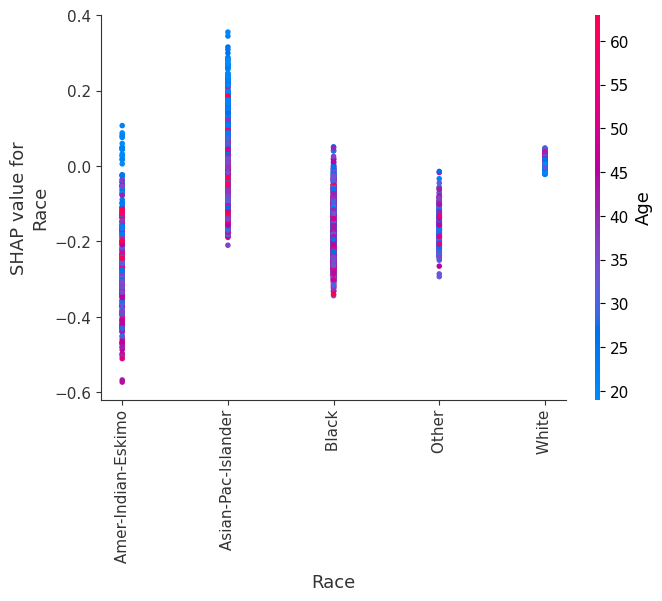

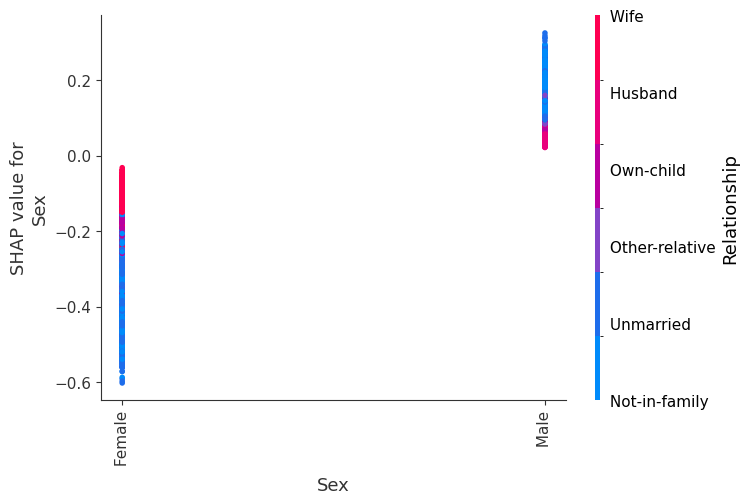

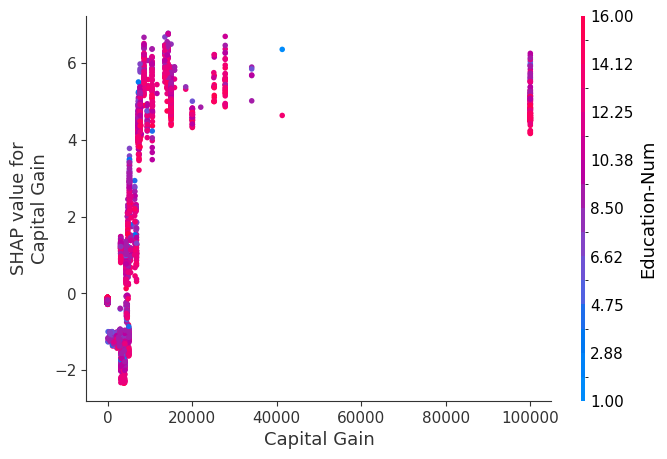

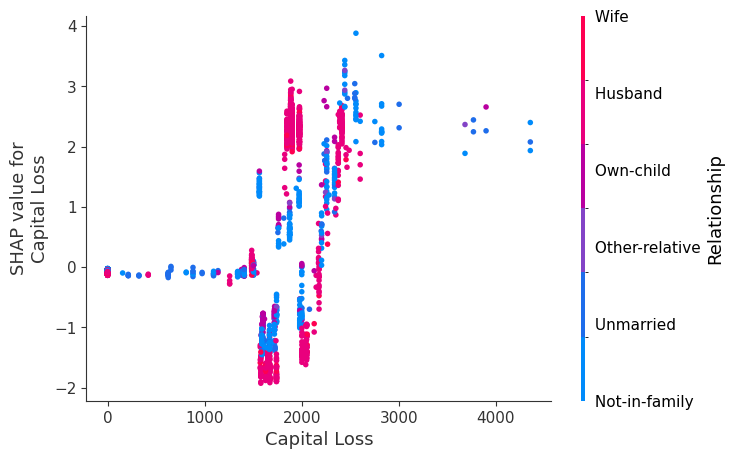

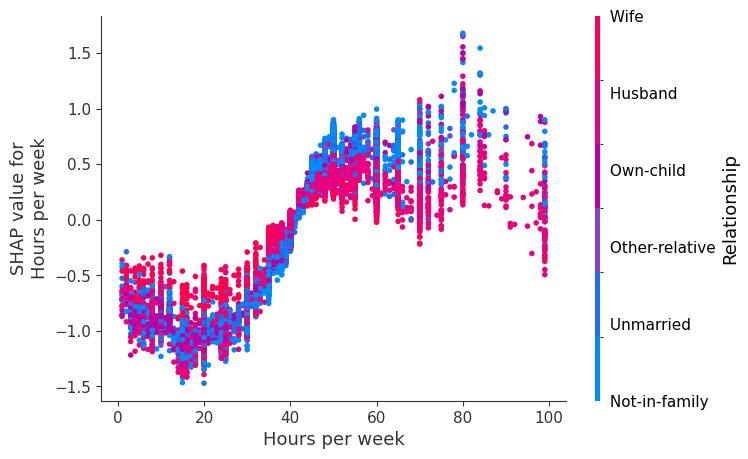

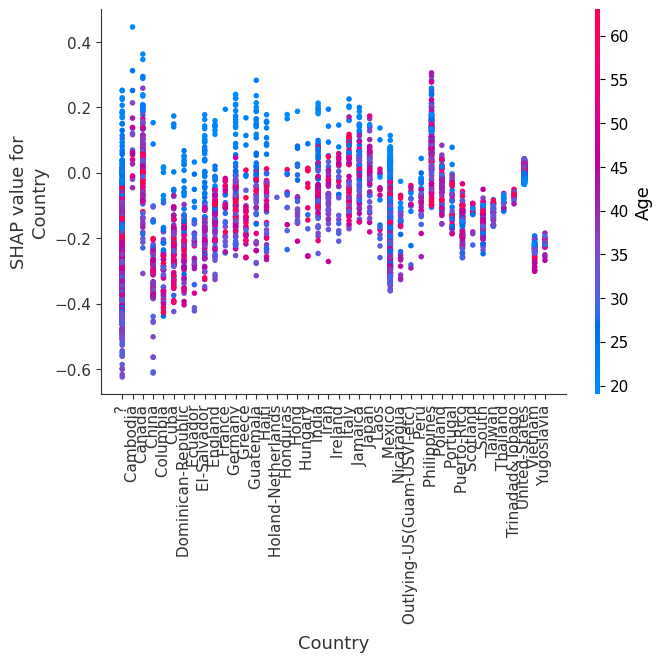

In [28]:
# Shap dependence plot
X_display, y_display = shap.datasets.adult(display=True)
for name in X.columns:
  shap.dependence_plot(name, shap_values, X, display_features=X_display)